# BUSINESS PROBLEM No.1

---

## **A. Background**

The Lending Club is a peer-to-peer lending site where members make loans to each other. The site makes anonymized data on loans and borrowers publicly available. 

## **B. Business Problem**

Using Lending Club loans data, the team would like to test below hypotheses on how different factors effecting each other

1. Interest rate is varied for different loan amounts (Less interest charged for high loan amounts).
2. Loan length is directly effecting interest rate.
3. Interest rate varies for different purpose of loans.
4. There is relationship between FICO scores and Home Ownership. It means that, People with owning home will have high FICO scores.  
    
## **C. Data available:** `LoansData.csv`

The data have the following variables: 

- `Amount.Requested`: The amount (in dollars) requested in the loan application.
- `Amount.Funded.By.Investors`: The amount (in dollars) loaned to the individual.
- `Interest.Rate`: The lending interest rate charged to the borrower.
- `Loan.Length`: The length of time (in months) of the loan. 
- `Loan.Purpose`: The purpose of the loan as stated by the applicant.
- `Debt.to.Income.Ratio`: The percentage of consumer’s gross income going toward paying debts.
- `State`: The abbreviation for the U.S. state of residence of the loan applicant.
- `Home.Ownership`: Indicator for whether the applicant owns, rents, or has a mortgage.
- `Monthly.Income`: The monthly income of the applicant (in dollars). 
- `FICO.Range`: A range indicating the applicants FICO score.
- `Open.CREDIT.Lines`: The number of open lines of credit at the time of application.
- `Revolving.CREDIT.Balance`: The total amount outstanding all lines of credit.
- `Inquiries.in.the.Last.6.Months`: Number of credit inquiries in the previous 6 months.
- `Employment.Length`: Length of time employed at current job.

**Relevant Statistical Tests**: Spearman correlation test, Shapiro-Wilk Normality Test (and Q-Q plot), Levene's Test, Mann-Whitney U-Test, Kruskal–Wallis Test, post-hoc Dunn's Test.

---

In [140]:
import os
import numpy as np
import scipy as sp
import statsmodels.api as sm
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter
from IPython.display import display

In [141]:
import statsmodels
import IPython

In [145]:
lib = ["numpy", 
       "scipy", 
       "statsmodels", 
       "pandas", 
       "matplotlib", 
       "seaborn", 
       "scikit_posthocs", 
       "kagglehub",
       "IPython"]
ver = [np.__version__, 
 sp.__version__, 
 statsmodels.__version__, 
 pd.__version__, 
 mpl.__version__, 
 sns.__version__, 
 sph.__version__, 
 kagglehub.__version__, 
 IPython.__version__]

with open("requirements.txt", "w") as f:
    for i in range(len(lib)):
        f.write(f"{lib[i]}=={ver[i]}\n")
    

## **I. Data Preprocessing**

### **1. Data Scanning**

In [92]:
# fetching data from source
data_source = "rishikumarrajvansh/hypothesis-testing-case-study"
data = "LoansData.csv"

df_loan = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  data_source,
  data,
)

In [93]:
# scanning the data
display(df_loan.head())

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,20000.0,20000.0,8.90%,36 months,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14.0,14272.0,2.0,< 1 year
1,19200.0,19200.0,12.12%,36 months,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12.0,11140.0,1.0,2 years
2,35000.0,35000.0,21.98%,60 months,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14.0,21977.0,1.0,2 years
3,10000.0,9975.0,9.99%,36 months,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10.0,9346.0,0.0,5 years
4,12000.0,12000.0,11.71%,36 months,credit_card,18.78%,NJ,RENT,3195.00,695-699,11.0,14469.0,0.0,9 years


In [94]:
display(df_loan.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Amount.Requested                2499 non-null   float64
 1   Amount.Funded.By.Investors      2499 non-null   float64
 2   Interest.Rate                   2498 non-null   object 
 3   Loan.Length                     2500 non-null   object 
 4   Loan.Purpose                    2500 non-null   object 
 5   Debt.To.Income.Ratio            2499 non-null   object 
 6   State                           2500 non-null   object 
 7   Home.Ownership                  2499 non-null   object 
 8   Monthly.Income                  2499 non-null   float64
 9   FICO.Range                      2498 non-null   object 
 10  Open.CREDIT.Lines               2497 non-null   float64
 11  Revolving.CREDIT.Balance        2497 non-null   float64
 12  Inquiries.in.the.Last.6.Months  24

None

In [95]:
display(df_loan.describe())

,Amount.Requested,Amount.Funded.By.Investors,Monthly.Income,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months
count,2499.000000,2499.000000,2499.000000,2497.000000,2497.000000,2497.000000
mean,12405.462185,12002.374186,5688.931321,10.072887,15223.184622,0.906688
std,7802.933666,7746.767348,3963.118185,4.507416,18281.015258,1.231149
min,1000.000000,-0.010000,588.500000,2.000000,0.000000,0.000000
25%,6000.000000,6000.000000,3500.000000,7.000000,5584.000000,0.000000
50%,10000.000000,10000.000000,5000.000000,9.000000,10948.000000,0.000000
75%,17000.000000,16000.000000,6800.000000,13.000000,18861.000000,1.000000
max,35000.000000,35000.000000,102750.000000,38.000000,270800.000000,9.000000


### **2. Data Quality Assessment**

In [96]:
# missing values
null_stats = pd.DataFrame(df_loan.isnull().sum())
null_stats.columns = ["amount"]
null_stats["percentage (%)"] = 100*null_stats["amount"]/len(df_loan)
display(null_stats)

,amount,percentage (%)
Amount.Requested,1,0.04
Amount.Funded.By.Investors,1,0.04
Interest.Rate,2,0.08
Loan.Length,0,0.00
Loan.Purpose,0,0.00
Debt.To.Income.Ratio,1,0.04
State,0,0.00
Home.Ownership,1,0.04
Monthly.Income,1,0.04
FICO.Range,2,0.08


In [97]:
# duplicates
print(df_loan.duplicated().sum())

0


In [98]:
# check inconsistencies/problems in categorical columns
object_cols = ["Loan.Length", 
              "Loan.Purpose", 
              "State", 
              "Home.Ownership",
              "FICO.Range",
              "Employment.Length",
              "Interest.Rate",
              "Debt.To.Income.Ratio",
             ]
for col in object_cols:
    print(col, df_loan[col].unique())



Loan.Length ['36 months' '60 months']
Loan.Purpose ['debt_consolidation' 'credit_card' 'other' 'moving' 'car' 'vacation'
 'home_improvement' 'house' 'major_purchase' 'educational' 'medical'
 'wedding' 'small_business' 'renewable_energy']
State ['SC' 'TX' 'CA' 'KS' 'NJ' 'CT' 'MA' 'LA' 'FL' 'DC' 'OH' 'AL' 'AZ' 'GA'
 'WV' 'NH' 'VA' 'NY' 'MD' 'HI' 'PA' 'WA' 'IL' 'NC' 'WI' 'SD' 'AK' 'DE'
 'MN' 'MO' 'RI' 'CO' 'NM' 'MI' 'OK' 'NV' 'UT' 'AR' 'KY' 'VT' 'OR' 'IA'
 'MT' 'IN' 'WY' 'MS']
Home.Ownership ['MORTGAGE' 'RENT' 'OWN' 'OTHER' 'NONE' nan]
FICO.Range ['735-739' '715-719' '690-694' '695-699' '670-674' '720-724' '705-709'
 '685-689' '665-669' '725-729' '730-734' '740-744' '760-764' '675-679'
 '765-769' '780-784' '830-834' '660-664' '710-714' '785-789' '750-754'
 '700-704' '680-684' '755-759' '790-794' '810-814' '775-779' '815-819'
 '745-749' '805-809' '800-804' '655-659' '770-774' '795-799' '640-644'
 '645-649' '820-824' '650-654' nan]
Employment.Length ['< 1 year' '2 years' '5 years' '9 years'

In [99]:
# check value range
num_cols = ["Amount.Requested", 
           "Amount.Funded.By.Investors", 
           "Monthly.Income", 
           "Open.CREDIT.Lines", 
           "Revolving.CREDIT.Balance", 
           "Inquiries.in.the.Last.6.Months",
          ]

for col in num_cols:
    print(col, df_loan[col].min(), df_loan[col].max(), df_loan[col].dtype)

Amount.Requested 1000.0 35000.0 float64
Amount.Funded.By.Investors -0.01 35000.0 float64
Monthly.Income 588.5 102750.0 float64
Open.CREDIT.Lines 2.0 38.0 float64
Revolving.CREDIT.Balance 0.0 270800.0 float64
Inquiries.in.the.Last.6.Months 0.0 9.0 float64


---
<u>**Report:**</u>

1. Data shape: 2500 rows, 14 columns.
2. Missing values: 12 out of 14 columns have missing values. Among them, 11 columns have 1-3 (<= 0.12%) missing values, and one column (`Employment.Length`) has 77 missing values (=~3.1%). `Employment.Length` is not relevant the hypothesis testings in this analysis, so it can be ignored. 
3. No duplicates found in the dataset
4. Columns's name normalization:
   - `Inquiries.in.the.Last.6.Months` to `Inquiries.In.The.Last.6.Months` 
5. Data types:
    - `Interest.Rate` and `Debt.To.Income.Ratio` should be converted to `float` (either as percentage or as rate)
    - `Loan.Length` can be either kept as categorical variable, or converted to `int`. In the later case, one should rename to `Loan.Length.Months`.
    - `FICO.Range` should be replaced by two new columns `FICO.Range.Min` and `FICO.Range.Max` storing the lower and upper bounds of the range (as `int` or `float`), correspondingly.
    - `Open.CREDIT.Lines` and `Inquiries.in.the.Last.6.Months` should be converted to `int` instead of `float`
    - `Amount.Funded.By.Investors` has negative amount (-0.01)

### **3. Data cleaning**

In [100]:
# Column name normalization
df_loan.rename(columns={'Inquiries.in.the.Last.6.Months':'Inquiries.In.The.Last.6.Months'}, inplace=True)

In [101]:
# (%) sign removal
df_loan["Interest.Rate"] = df_loan["Interest.Rate"].str.replace("%", "", regex=False)
df_loan["Interest.Rate"] = pd.to_numeric(df_loan["Interest.Rate"], errors="coerce")
df_loan.rename(columns={'Interest.Rate':'Interest.Rate.Pct'}, inplace=True)

df_loan["Debt.To.Income.Ratio"] = df_loan["Debt.To.Income.Ratio"].str.replace("%", "", regex=False)
df_loan["Debt.To.Income.Ratio"] = pd.to_numeric(df_loan["Debt.To.Income.Ratio"], errors="coerce")
df_loan.rename(columns={'Debt.To.Income.Ratio':'Debt.To.Income.Ratio.Pct'}, inplace=True)

In [102]:
# Convert Loan.Length to interger
df_loan["Loan.Length"] = df_loan["Loan.Length"].str.replace(" months", "", regex=False)
df_loan["Loan.Length"] = pd.to_numeric(df_loan["Loan.Length"], errors="coerce")
df_loan.rename(columns={'Loan.Length':'Loan.Length.Months'}, inplace=True)

In [103]:
# FICO limits
df_loan["FICO.Range.Min"] = df_loan["FICO.Range"].str.split("-").str[0]
df_loan["FICO.Range.Max"] = df_loan["FICO.Range"].str.split("-").str[1]
df_loan["FICO.Range.Min"] = pd.to_numeric(df_loan["FICO.Range.Min"], errors="coerce")
df_loan["FICO.Range.Max"] = pd.to_numeric(df_loan["FICO.Range.Max"], errors="coerce")

In [104]:
# Convert
df_loan["Open.CREDIT.Lines"] = df_loan["Open.CREDIT.Lines"].astype('Int64')
df_loan["Inquiries.In.The.Last.6.Months"] = df_loan["Inquiries.In.The.Last.6.Months"].astype('Int64')


In [105]:
# Irrelevant column removal
df_loan.drop(["Employment.Length", "FICO.Range"], axis=1, inplace=True)

In [106]:
# remove negative amount = replace by NaN
df_loan.loc[
    df_loan["Amount.Funded.By.Investors"] < 0,
    "Amount.Funded.By.Investors"
] = np.nan

In [107]:
# missing values imputation: for columns not related to the hypothesis testing
median_inquiries = df_loan["Inquiries.In.The.Last.6.Months"].median()
median_CREDIT_balance = df_loan["Revolving.CREDIT.Balance"].median()
median_CREDIT_lines = df_loan["Open.CREDIT.Lines"].median()
median_income = df_loan["Monthly.Income"].median()
median_debt_income = df_loan["Debt.To.Income.Ratio.Pct"].median()

df_loan.fillna({
    "Inquiries.In.The.Last.6.Months": median_inquiries,
    "Revolving.CREDIT.Balance": median_CREDIT_balance,
    "Open.CREDIT.Lines": median_CREDIT_lines,
    "Monthly.Income": median_income,
    "Debt.To.Income.Ratio.Pct": median_debt_income,
}, inplace=True)

# missing values removal: for columns related to the hypothesis testing
df_loan = df_loan.dropna(ignore_index=True)

In [108]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492 entries, 0 to 2491
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Amount.Requested                2492 non-null   float64
 1   Amount.Funded.By.Investors      2492 non-null   float64
 2   Interest.Rate.Pct               2492 non-null   float64
 3   Loan.Length.Months              2492 non-null   int64  
 4   Loan.Purpose                    2492 non-null   object 
 5   Debt.To.Income.Ratio.Pct        2492 non-null   float64
 6   State                           2492 non-null   object 
 7   Home.Ownership                  2492 non-null   object 
 8   Monthly.Income                  2492 non-null   float64
 9   Open.CREDIT.Lines               2492 non-null   Int64  
 10  Revolving.CREDIT.Balance        2492 non-null   float64
 11  Inquiries.In.The.Last.6.Months  2492 non-null   Int64  
 12  FICO.Range.Min                  24

In [109]:
df_loan

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate.Pct,Loan.Length.Months,Loan.Purpose,Debt.To.Income.Ratio.Pct,State,Home.Ownership,Monthly.Income,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.In.The.Last.6.Months,FICO.Range.Min,FICO.Range.Max
0,20000.0,20000.00,8.90,36,debt_consolidation,14.90,SC,MORTGAGE,6541.67,14,14272.0,2,735.0,739.0
1,19200.0,19200.00,12.12,36,debt_consolidation,28.36,TX,MORTGAGE,4583.33,12,11140.0,1,715.0,719.0
2,35000.0,35000.00,21.98,60,debt_consolidation,23.81,CA,MORTGAGE,11500.00,14,21977.0,1,690.0,694.0
3,10000.0,9975.00,9.99,36,debt_consolidation,14.30,KS,MORTGAGE,3833.33,10,9346.0,0,695.0,699.0
4,12000.0,12000.00,11.71,36,credit_card,18.78,NJ,RENT,3195.00,11,14469.0,0,695.0,699.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2487,30000.0,29950.00,16.77,60,debt_consolidation,19.23,NY,MORTGAGE,9250.00,15,45880.0,1,705.0,709.0
2488,16000.0,16000.00,14.09,60,home_improvement,21.54,MD,OWN,8903.25,18,18898.0,1,740.0,744.0
2489,10000.0,10000.00,13.99,36,debt_consolidation,4.89,PA,MORTGAGE,2166.67,4,4544.0,0,680.0,684.0
2490,6000.0,6000.00,12.42,36,major_purchase,16.66,NJ,RENT,3500.00,8,7753.0,0,675.0,679.0


## **II. Exploratory Data Analysis (EDA): Distributions**

### **1. Univariate Distribution**

In [110]:
# Numerical columns stats
num_cols = ["Amount.Funded.By.Investors",
            "Amount.Requested",
            "Interest.Rate.Pct",
            "Debt.To.Income.Ratio.Pct",
            "Monthly.Income",
            "Open.CREDIT.Lines",
            "Revolving.CREDIT.Balance",
            "Inquiries.In.The.Last.6.Months",
            "FICO.Range.Min",
            "FICO.Range.Max", 
           ]

log_scale = [None]*len(num_cols)
log_scale[4] = log_scale[6] = True

display(df_loan[num_cols].describe())

,Amount.Funded.By.Investors,Amount.Requested,Interest.Rate.Pct,Debt.To.Income.Ratio.Pct,Monthly.Income,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.In.The.Last.6.Months,FICO.Range.Min,FICO.Range.Max
count,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.0,2492.000000,2492.0,2492.000000,2492.000000
mean,12005.059434,12407.363563,13.065381,15.375983,5688.090971,10.073034,15210.474719,0.903291,705.961075,709.961075
std,7744.531300,7805.347485,4.181171,7.507953,3967.325554,4.507129,18287.528918,1.226251,35.043262,35.043262
min,0.000000,1000.000000,5.420000,0.000000,588.500000,2.0,0.000000,0.0,640.000000,644.000000
25%,6000.000000,6000.000000,10.160000,9.747500,3494.200000,7.0,5566.250000,0.0,680.000000,684.000000
50%,10000.000000,10000.000000,13.110000,15.320000,5000.000000,9.0,10946.000000,0.0,700.000000,704.000000
75%,16000.000000,17000.000000,15.800000,20.672500,6800.000000,13.0,18843.750000,1.0,725.000000,729.000000
max,35000.000000,35000.000000,24.890000,34.910000,102750.000000,38.0,270800.000000,9.0,830.000000,834.000000


(0.0, 1.0, 0.0, 1.0)

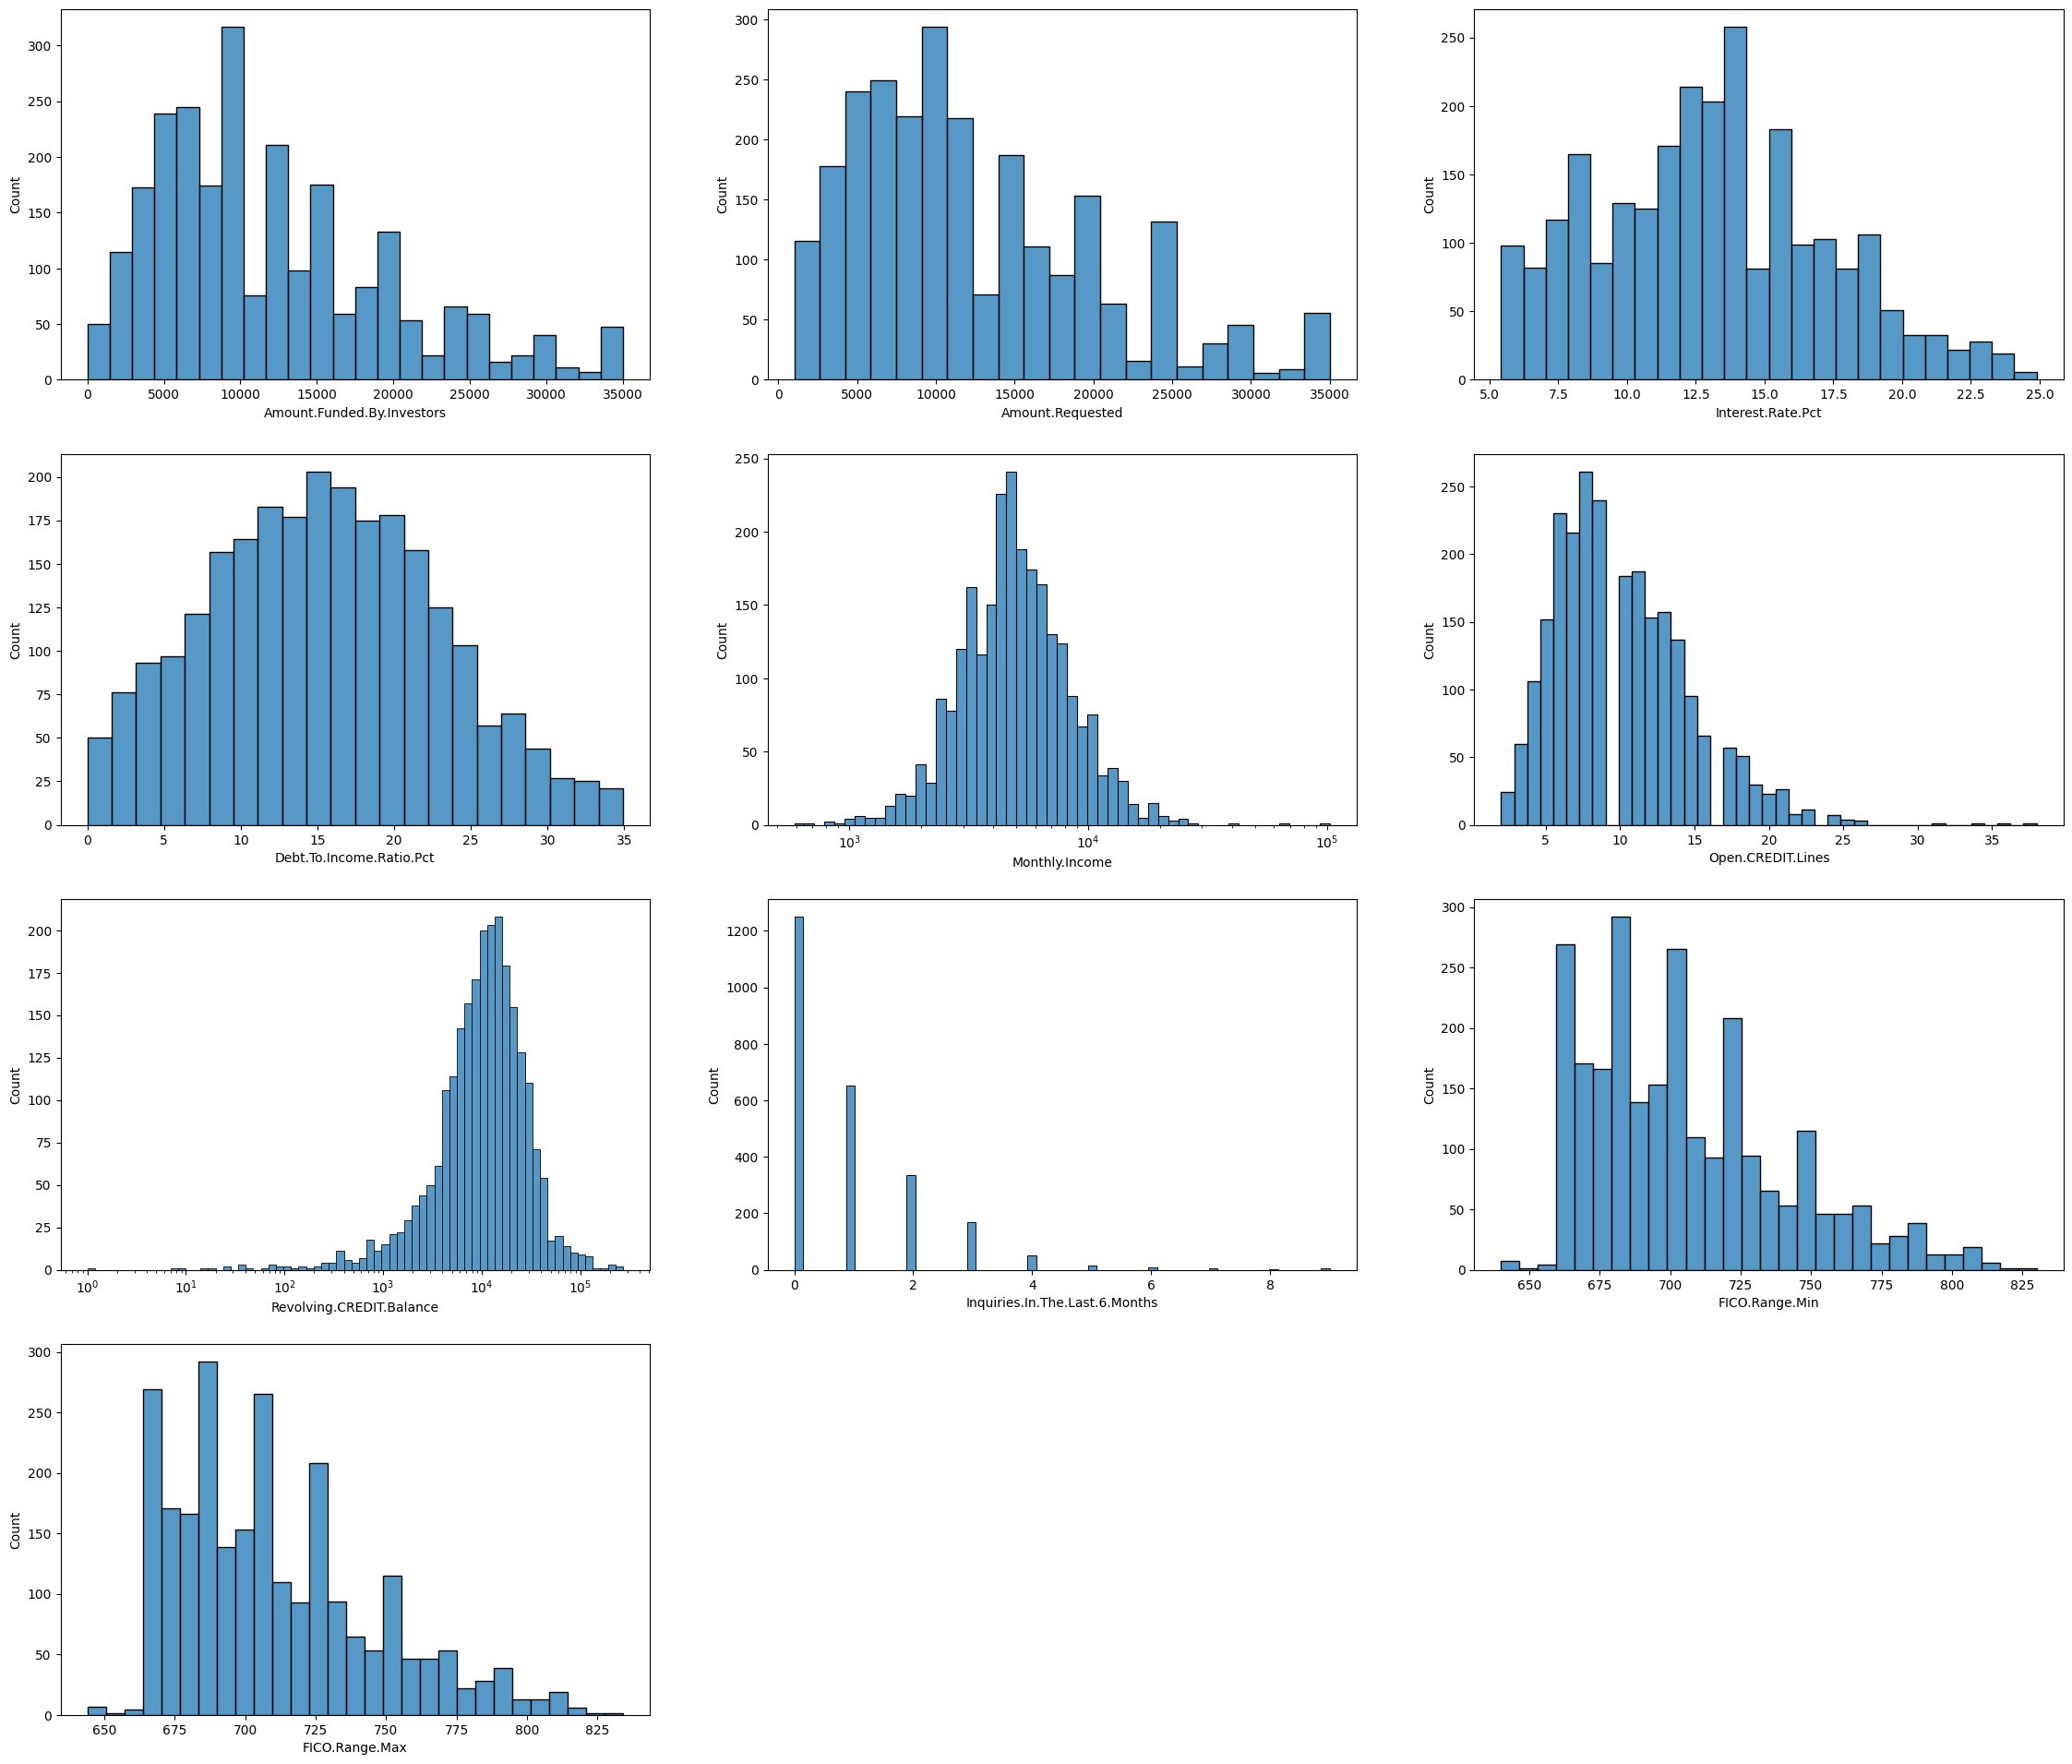

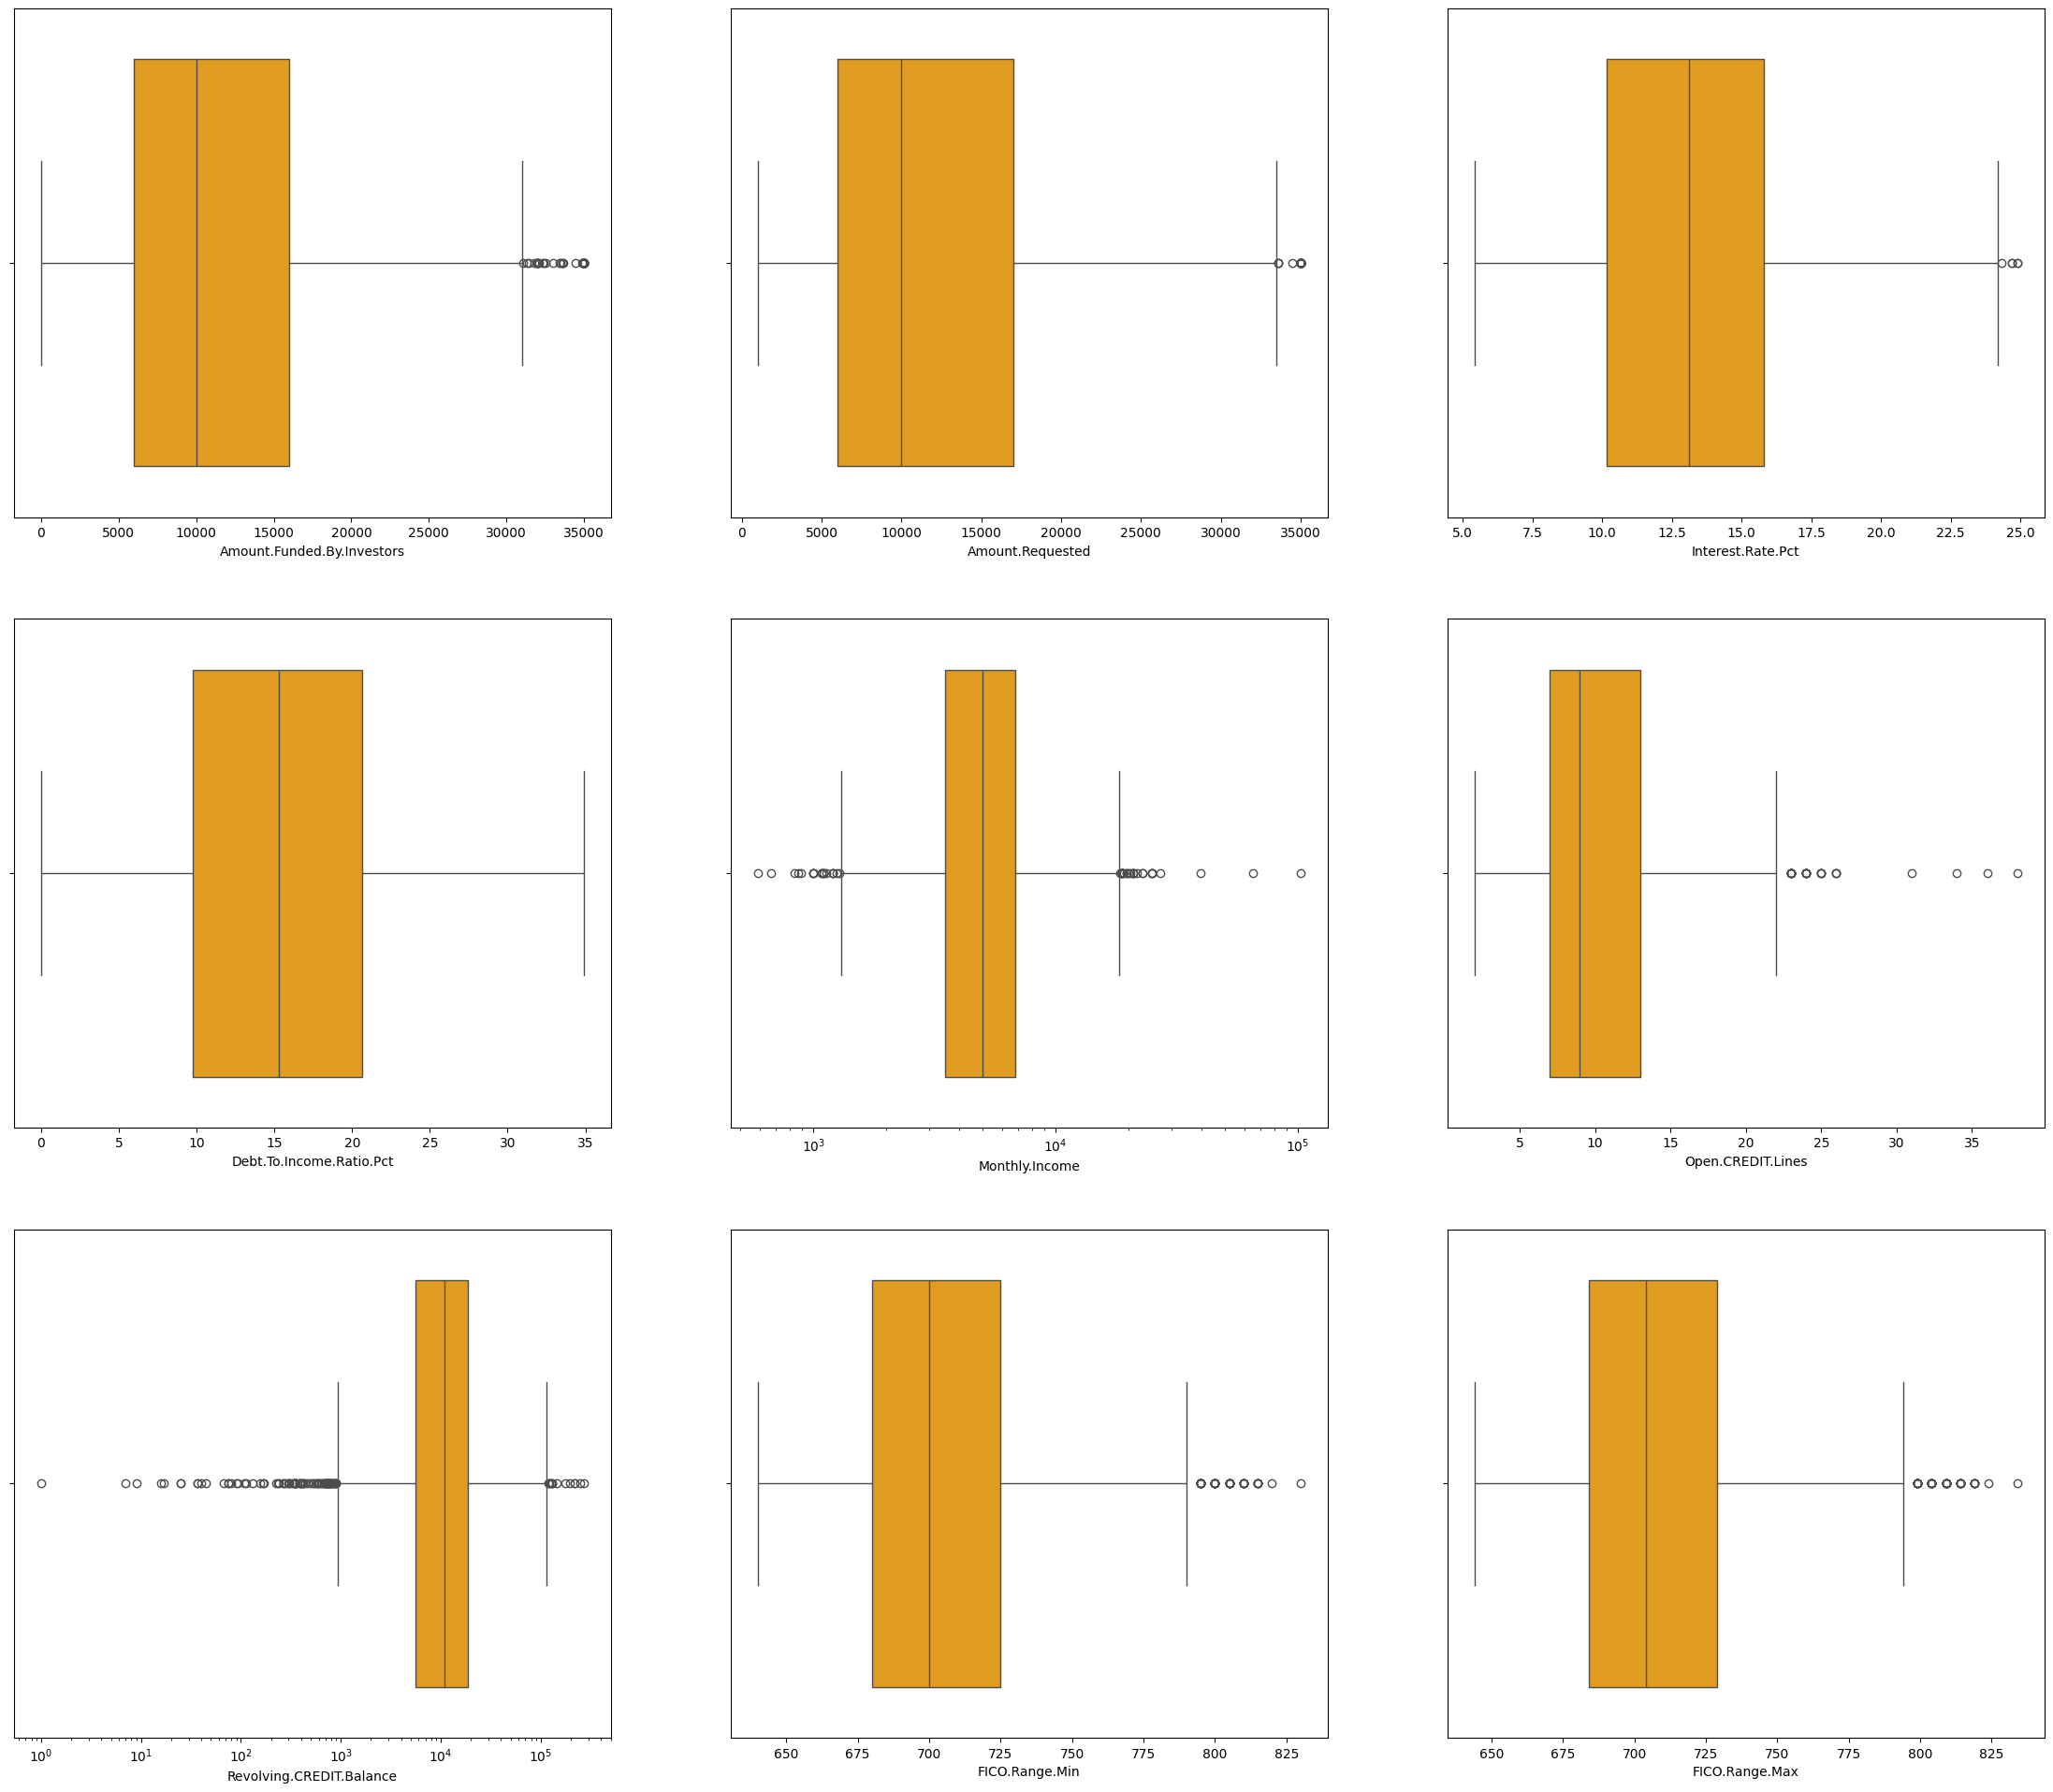

In [111]:
# # Numerical columns visualization
fig_num_hist, axs_num_hist = plt.subplots(len(num_cols)//3+1,3,figsize=(28,24))
fig_num_box, axs_num_box = plt.subplots(len(num_cols)//3,3,figsize=(28,24))
i, j = 0, 0
for col in num_cols:
    sns.histplot(data=df_loan, x=col, 
                 ax=axs_num_hist[i][j], 
                 log_scale=log_scale[num_cols.index(col)])
    
    if j==2:
        j=0
        i+=1
    else:
        j+=1
i, j = 0, 0
for col in num_cols:
    if col not in ["Loan.Accepted.Pct", "Inquiries.In.The.Last.6.Months"]:
        sns.boxplot(data=df_loan, x=col, 
                    ax=axs_num_box[i][j], 
                    color="orange", 
                    log_scale=log_scale[num_cols.index(col)])
        if j==2:
            j=0
            i+=1
        else:
            j+=1

    
axs_num_hist[-1][-1].axis('off')
axs_num_hist[-1][-2].axis('off')

**Comment:**

- Loan amount mostly centers in the range $5000\$$ -$16000\$$. The loan distribution is skewed.
- interest rate mostly centers in the range $10.0\%$ - $16.0\%$

In [112]:
# categorical columns stats: frequency table
categorical_cols = [col for col in df_loan.columns.tolist() if col not in num_cols]
for col in categorical_cols:
    print(df_loan[col].value_counts())

Loan.Length.Months
36    1944
60     548
Name: count, dtype: int64
Loan.Purpose
debt_consolidation    1303
credit_card            442
other                  201
home_improvement       152
major_purchase         101
small_business          87
car                     50
wedding                 38
medical                 30
moving                  29
vacation                21
house                   20
educational             14
renewable_energy         4
Name: count, dtype: int64
State
CA    430
NY    255
TX    174
FL    169
IL    101
GA     98
PA     96
NJ     92
VA     78
MA     73
OH     70
MD     68
NC     64
CO     60
WA     57
CT     50
AZ     46
MI     45
AL     38
MN     38
MO     33
NV     32
OR     30
SC     28
WI     26
KY     23
LA     22
KS     21
OK     21
UT     16
WV     15
NH     15
RI     15
AR     13
NM     13
HI     12
DC     11
AK     11
DE      8
MT      7
VT      5
SD      4
WY      4
IN      3
IA      1
MS      1
Name: count, dtype: int64
Home.Ownership
MORTGAGE 

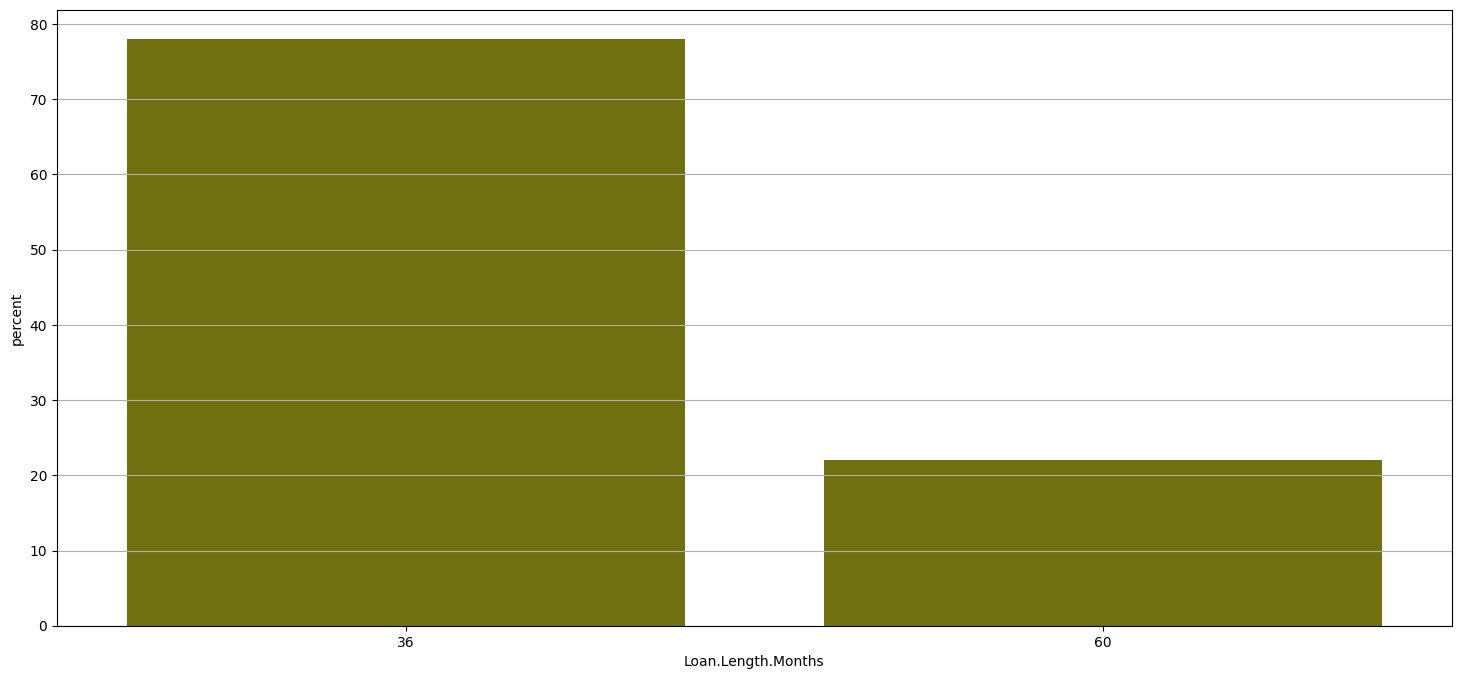

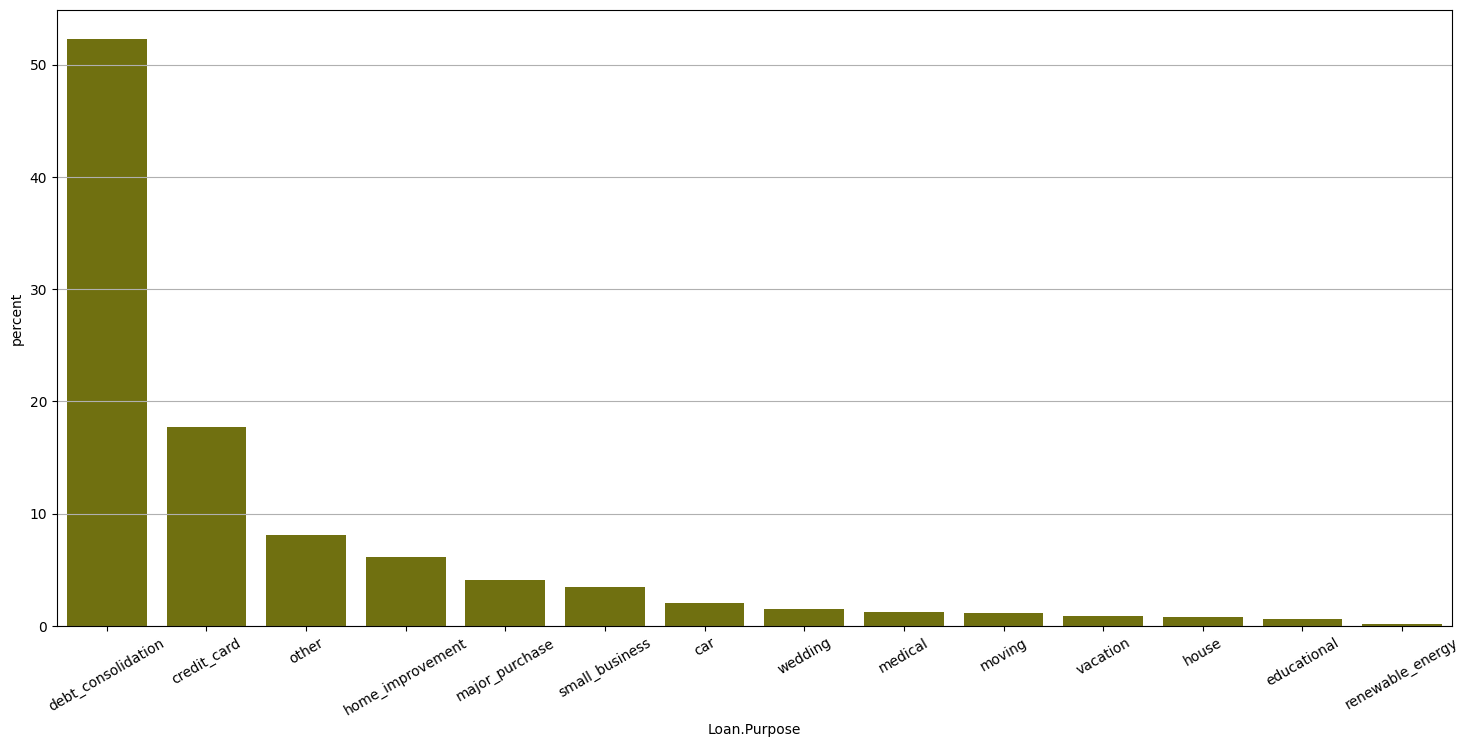

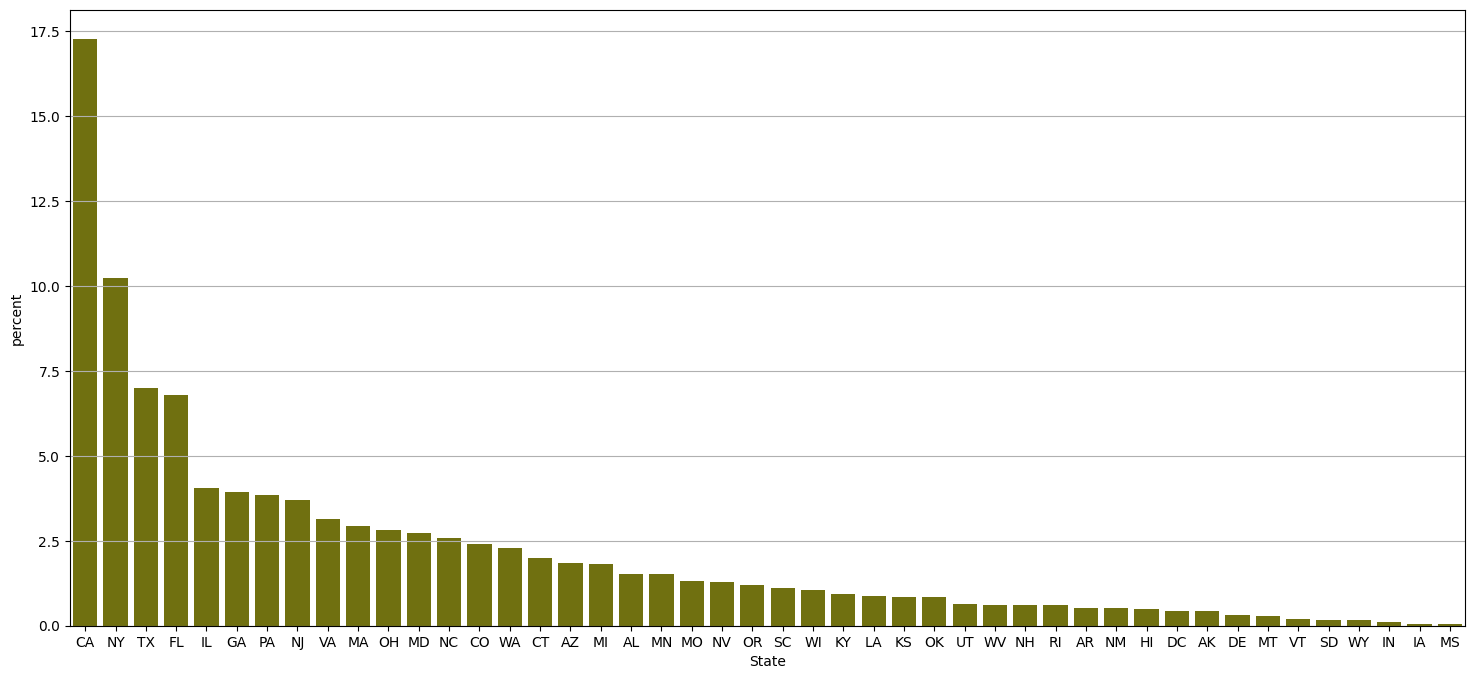

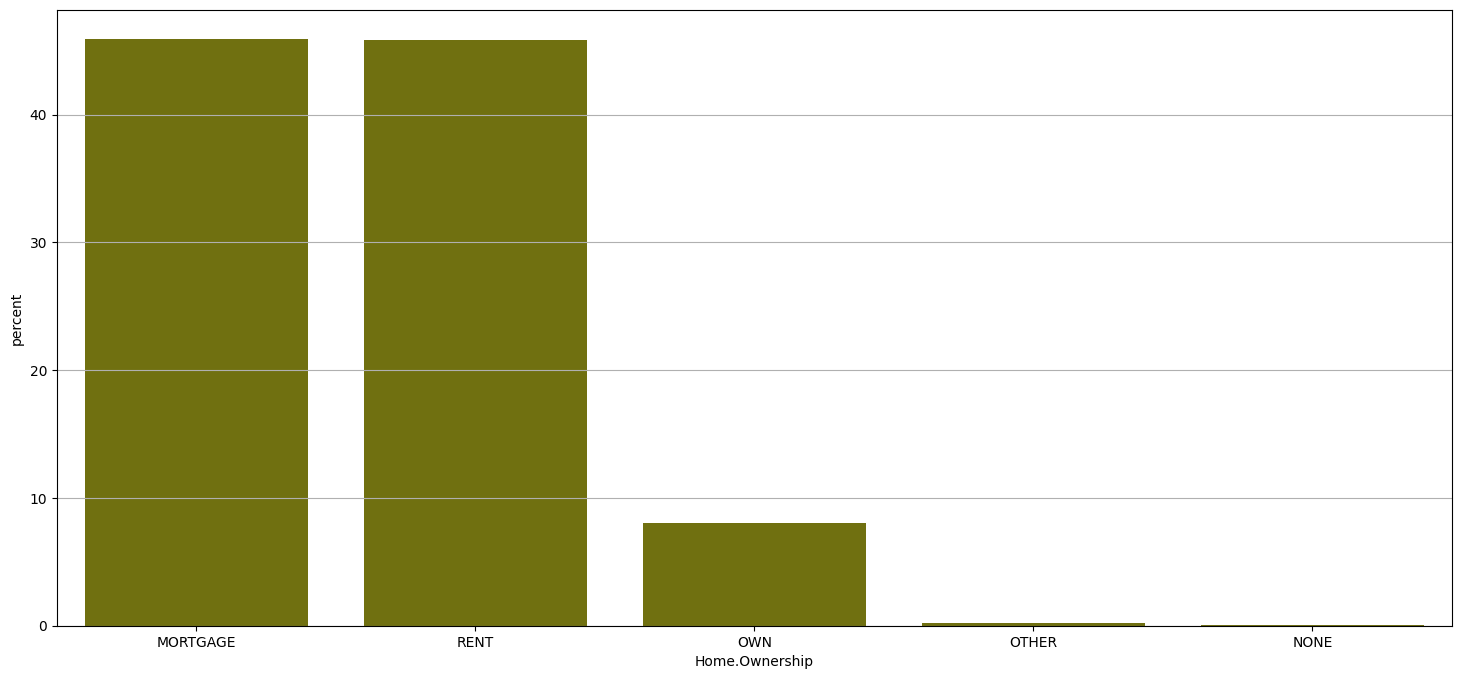

In [113]:
# categorical columns visualization
order_purpose = df_loan["Loan.Purpose"].value_counts().index
order_state = df_loan["State"].value_counts().index
order_ownership = df_loan["Home.Ownership"].value_counts().index

for col in categorical_cols:
    order = df_loan[col].value_counts().index
    plt.figure(figsize=(18,8))
    sns.countplot(data=df_loan, x=col, order=order, stat='percent',color='olive')
    if col =="Loan.Purpose":
        plt.xticks(rotation=30)
    plt.grid(axis='y')
    plt.show()

**Comment:**

- Most of loan are in 3 years (~80%), and for the purpose of debt consolidation (>50%).
- Home ownership states of most people with loan are mortgage and rent (each ~45%). People owning home are of small proportion (<10%).   
- More people from California have loan.

### **2. Bivariate Distribution**

<Axes: xlabel='Amount.Funded.By.Investors', ylabel='Interest.Rate.Pct'>

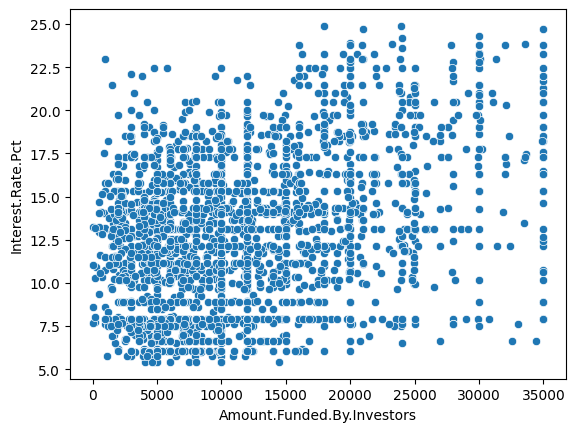

In [114]:
# Interest rate vs. loan amounts
sns.scatterplot(data=df_loan, x="Amount.Funded.By.Investors",y="Interest.Rate.Pct")

**Comment:** There seems to be a positive relation between the Interest rate and Loan Amount. However this relationship is not clear.


<Axes: xlabel='Loan.Length.Months', ylabel='Amount.Funded.By.Investors'>

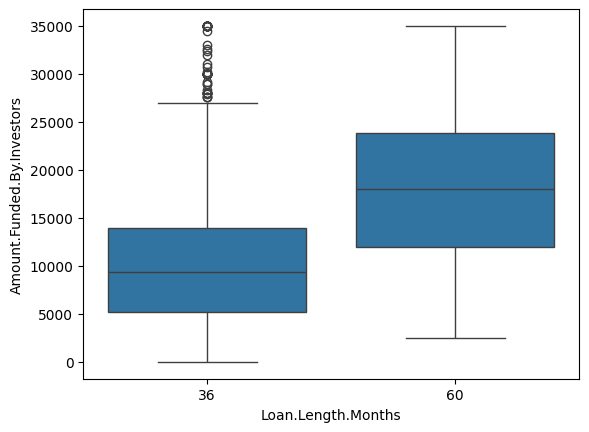

In [115]:
#
sns.boxplot(data=df_loan, y="Amount.Funded.By.Investors", x="Loan.Length.Months")

<Axes: xlabel='Loan.Length.Months', ylabel='Interest.Rate.Pct'>

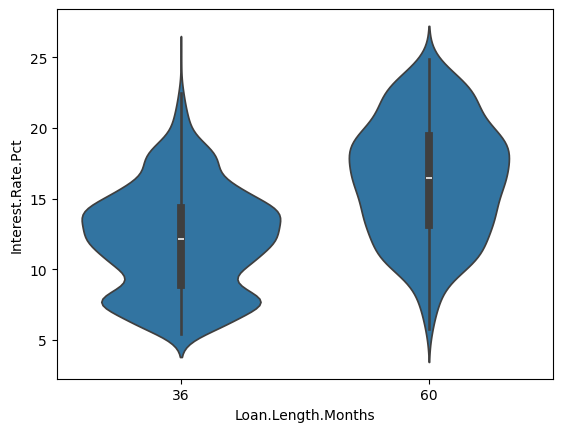

In [116]:
#  Loan length vs. interest rate
sns.violinplot(data=df_loan, y="Interest.Rate.Pct", x="Loan.Length.Months")

**Comment:**

- The loans with loan length of 5 years tend to have higher loan amount and higher interest rate.

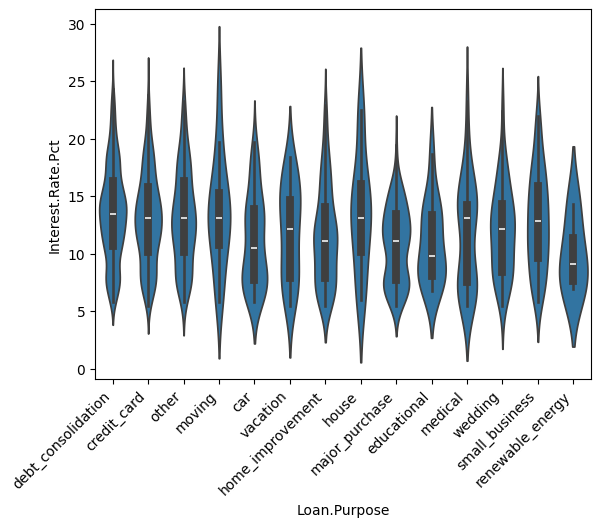

In [117]:
# Interest rate vs. different purpose of loans
sns.violinplot(data=df_loan, y="Interest.Rate.Pct", x="Loan.Purpose")
ax = plt.gca()
plt.setp(ax.get_xticklabels(), ha='right', rotation=45)
plt.show()

**Comment:** There is a variation among different purposes. For example, there is a difference in the distribution of "Car" purpose and "debt consolidation" purpose. However some groups have similar distributions, such as debt consolidation and credit card.

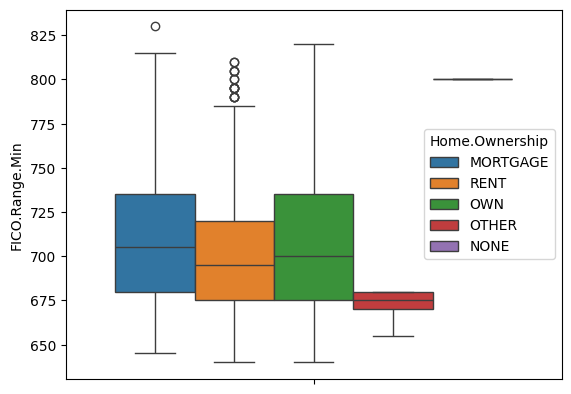

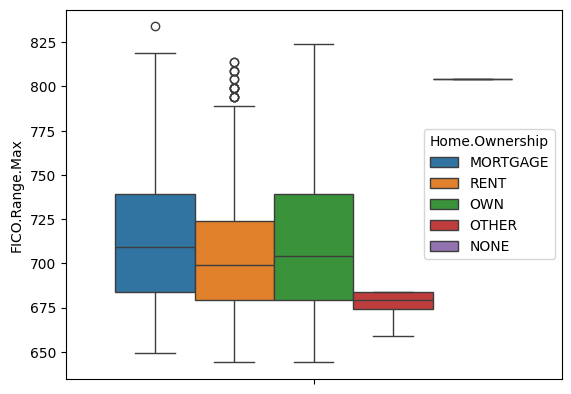

In [118]:
# FICO scores and Home Ownership.
sns.boxplot(data=df_loan, y="FICO.Range.Min", hue="Home.Ownership")
plt.show()
sns.boxplot(data=df_loan, y="FICO.Range.Max", hue="Home.Ownership")
plt.show()

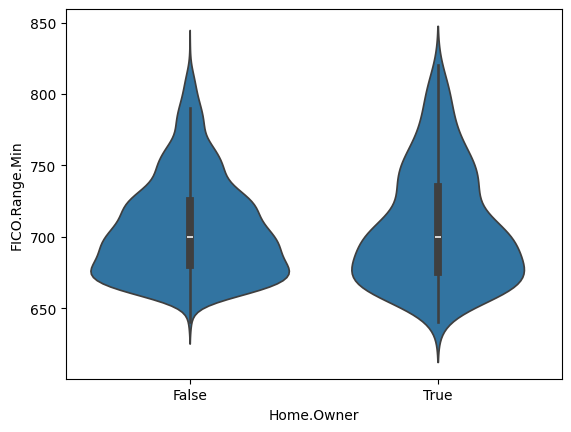

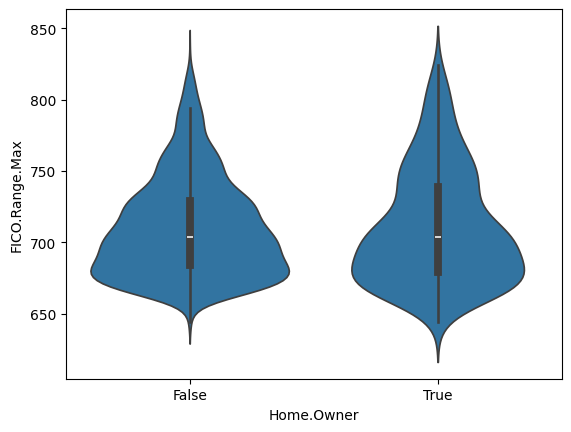

In [119]:
df_loan["Home.Owner"] = df_loan["Home.Ownership"]=="OWN"
sns.violinplot(data=df_loan, y="FICO.Range.Min", x="Home.Owner")
plt.show()
sns.violinplot(data=df_loan, y="FICO.Range.Max", x="Home.Owner")
plt.show()

**Comment:** The distributions of FICO scores of different home ownership groups are not clearly discriminated.

## **II. Exploratory Data Analysis (EDA): Hypothesis testingµ**

### **1. Interest rate vs. loan amounts**

We want to test 
- if less interest is charged for higher loan amounts,
- if more interest is charged for higher loan amounts

Here, interest rate and loan amounts are not normally distributed. To test this relationship statistically, we use the Spearman correlation ($\rho$) test. We performed two tests: left- and right-tailed Spearman test.

**<u>a. Left-tailed test:</u>**

**Null hypothesis $H_0$**: There is no negative correlation between loan amounts and interest rate ($\rho \ge 0$).

**Alternative hypothesis $H_1$**: There is a negative correlation ($\rho<0$) 

**Significant level**: $\alpha = 0.05$. The $H_0$ will be rejected if p-value is less than $\alpha$.

**<u>b. Right-tailed test:</u>**

**Null hypothesis $H_0$**: There is no positive correlation between loan amounts and interest rate ($\rho \le 0$).

**Alternative hypothesis $H_1$**: There is a positive correlation ($\rho>0$) 

**Significant level**: $\alpha = 0.05$. The $H_0$ will be rejected if p-value is less than $\alpha$.








In [120]:
# left-tailed
res_left = sp.stats.spearmanr(df_loan["Amount.Funded.By.Investors"], 
                         df_loan["Interest.Rate.Pct"], 
                         alternative='less')
p_val_left = res_left.pvalue
correlation_left = res_left.statistic

# right-tailed
res_right = sp.stats.spearmanr(df_loan["Amount.Funded.By.Investors"], 
                         df_loan["Interest.Rate.Pct"], 
                         alternative='greater')
p_val_right = res_right.pvalue
correlation_right = res_right.statistic

# print out
print(f"Left-sided {p_val_left = :.3f}")
print(f"{correlation_left = :.3f}")
print("")
print(f"Right-sided {p_val_right = :.3f}")
print(f"{correlation_right = :.3f}")

Left-sided p_val_left = 1.000
correlation_left = 0.285

Right-sided p_val_right = 0.000
correlation_right = 0.285


<div class="alert alert-block alert-success">

<b>Conclusion:</b>

- <i>Left-sided test</i>: Fail to reject $H_0$. There is absolutely no statistical evidence of a negative relationship between interest rate and loan amounts.

- <i>Right-sided test</i>: Reject $H_0$. There is a statistical evidence of a positive relationship between interest rate and loan amounts. The correlation is 0.285, which indicates a weak-to-medium correlation.

So, higher interest rate is likely charged for higher loan. 
</div>

### **2. Is Loan length directly effecting interest rate ??** 

Before deciding which test to be used, let me check the *normality* and *homogeneity of variance* of the interest rate in both length groups. The *independence of observations* is assumed (no duplicates were found). The sample size of each group is >500.

**Normality test: Shapiro-Wilk test and Q-Q plot**

60-month Normality p-value: 2.2301324218332783e-05
Reject H0. Warning: The rate distribution of 60-month length is not normal
36-month Normality p-value: 1.349441982589804e-16
Reject H0. Warning: The rate distribution of 36-month length is not normal


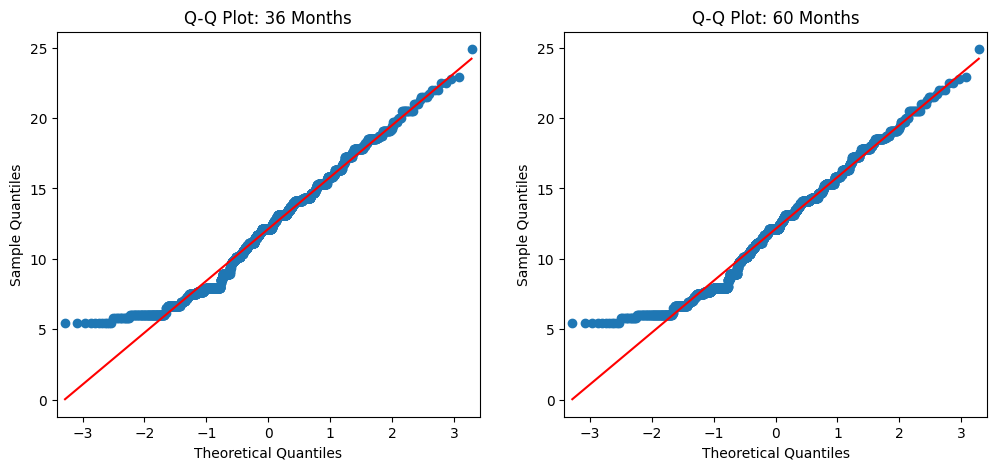

In [121]:
# normality check
group_36 = df_loan[df_loan['Loan.Length.Months'] == 36]['Interest.Rate.Pct']
group_60 = df_loan[df_loan['Loan.Length.Months'] == 60]['Interest.Rate.Pct']

# Shapiro-Wilk Test (Null: Data is normal, Alternative: Data is not normal, alpha=0.05)
stat_36, p_36 = sp.stats.shapiro(group_36)
stat_60, p_60 = sp.stats.shapiro(group_60)

print(f"60-month Normality p-value: {p_60}")
if p_60 < 0.05:
    print("Reject H0. Warning: The rate distribution of 60-month length is not normal")
else:
    print("Fail to reject H0. Assumption met: The distribution of 60-month length is normal.")

print(f"36-month Normality p-value: {p_36}")
if p_36 < 0.05:
    print("Reject H0. Warning: The rate distribution of 36-month length is not normal")
else:
    print("Fail to reject H0. Assumption met: The distribution of 36-month length is normal.")

# Visual check: Q-Q Plot
fig_norm, ax_norm = plt.subplots(1, 2, figsize=(12, 5))
sm.qqplot(group_36, line='s', ax=ax_norm[0])
ax_norm[0].set_title("Q-Q Plot: 36 Months")
sm.qqplot(group_36, line='s', ax=ax_norm[1])
ax_norm[1].set_title("Q-Q Plot: 60 Months")
plt.show()


**Homogeneity of Variance: Levene's test**

In [134]:
# Levene's Test (H0: Variances are equal, H1: Variances not equal, alpha=0.05)
stat_levene, p_levene = sp.stats.levene(group_36, group_60)

print(f"Levene’s Test p-value: {p_levene}")

if p_levene < 0.05:
    print("Reject H0. Warning: Variances are NOT equal")
else:
    print("Fail to reject H0. Assumption met: Variances are equal.")

Levene’s Test p-value: 7.72713414854803e-05The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

Reject H0. Warning: Variances are NOT equal


**Comment**: So two groups have non-normal distributions with different variances. 

I will use the nonparametric Mann–Whitney U-test to test the difference of two groups' distributions.

**Null hypothesis (H0):** The rate distributions in the two groups are the same.

**Alternative hypothesis (H1):** The rate distributions in the two groups are NOT the same.

**Significant level:** $\alpha=0.5$

In [123]:
# Perform Mann-Whitney U test
U_statistic, p_value = sp.stats.mannwhitneyu(group_36, group_60)

# Print the result
print(f'The U-statistic is {U_statistic:.2f} and the p-value is {p_value:}')


if p_value < 0.05:
    print("Reject H0. Warning: Two distributions are NOT the same")
else:
    print("""Fail to reject H0. Assumption met: two distributions are the same""")

The U-statistic is 243281.00 and the p-value is 2.5752571742191637e-84
Reject H0. Warning: Two distributions are NOT the same


<div class="alert alert-block alert-success">

<b>Conclusion:</b> The above violin plot in rate vs. length and the Mann Whitney U test suggest that loan length statistically significantly affects the interest rate.
</div>

### **3. Does Interest Rate vary significantly for different purpose of loans?**

In this test, we are comparing to multiple groups (purpose of loans). Depending to the nature of distributions, we adopt either a parametric ANOVA test or the non-parametric Kruskal–Wallis test.

What to check: paired or unpaired, normal or not normal, same variance or not. 


In [124]:
# Prepare the groups (List of interest rates for each purpose)
purpose_groups = [group['Interest.Rate.Pct'].values for name, group in df_loan.groupby('Loan.Purpose')]

In [125]:
# normality S-W test
purpose_pvals = []
for group in purpose_groups:
    stat, pval = sp.stats.shapiro(group)
    purpose_pvals.append(pval)

if any(p < 0.05 for p in purpose_pvals):
    print("Normality assumption is violated!")
else:
    print("Normality assumption is met!")

Normality assumption is violated!


We don't need to check for the assumption of homogeneity of variance. Here we choose the non-parametric Kruskal-Wallis (K-W) test to check if there is significant difference between AT LEAST two groups. Note that this test does not tell us where the difference is (if any). In case of yes, we should move onto a further test, the Dunn’s Test, to figure out the "where".

**<u>K-W test:</u>**

**Null hypothesis ($H_0$):** No sigificant difference between the distributions of any two groups.

**Alternative hypothesis ($H_1$):** A sigificant difference found between the distributions of at least two groups.

**Significant level:** $\alpha=0.05$

In [126]:
# Run Kruskal-Wallis H-test
h_stat, p_kruskal = sp.stats.kruskal(*purpose_groups)

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"Global P-value: {p_kruskal:.4e}")

if p_kruskal < 0.05:
    print("Result: Reject H0. Significant difference found between at least two groups.")
else:
    print("Result: Fail to reject H0. Statistically, no significant difference found.")

Kruskal-Wallis H-statistic: 94.5617
Global P-value: 1.8627e-14
Result: Reject H0. Significant difference found between at least two groups.


So, now, the K-W test indicates that *"Significant difference found between at least two groups"*(pval<0.05). We continue with the Dunn'test.


In [127]:
import scikit_posthocs as sph

# Run Dunn's test with Bonferroni correction
dunn_results_purpose = sph.posthoc_dunn(df_loan, val_col='Interest.Rate.Pct', group_col='Loan.Purpose', p_adjust='bonferroni')

dunn_pairs_purpose = dunn_results_purpose.stack().reset_index()
dunn_pairs_purpose.columns = ['Group 1', 'Group 2', 'p-value']

# Filter for significant pairs (p < 0.05) 
# also filter out self-comparisons (where Group 1 == Group 2)
significant_pairs_purpose = dunn_pairs_purpose[
    (dunn_pairs_purpose['p-value'] < 0.05) & 
    (dunn_pairs_purpose['Group 1'] != dunn_pairs_purpose['Group 2'])
]

# Remove duplicates (e.g., Group A vs B and Group B vs A are the same)
# We sort the names and drop duplicates
significant_pairs_purpose = significant_pairs_purpose.assign(
    pair=lambda x: x.apply(lambda row: tuple(sorted([row['Group 1'], row['Group 2']])), axis=1)
).drop_duplicates('pair').drop(columns='pair')

# 5. Print the results
if significant_pairs_purpose.empty:
    print("No pairs found with a p-value < 0.05.")
else:
    print("Significant Pairs (p < 0.05):")
    print(significant_pairs_purpose.to_string(index=False))

Significant Pairs (p < 0.05):
           Group 1            Group 2      p-value
               car debt_consolidation 4.130024e-03
       credit_card   home_improvement 6.952086e-03
       credit_card     major_purchase 8.023253e-05
debt_consolidation   home_improvement 6.303580e-07
debt_consolidation     major_purchase 9.807671e-09
  home_improvement              other 3.450142e-02
    major_purchase              other 5.405568e-04


<div class="alert alert-block alert-success">

<b>Conclusion:</b> 

-  K-W test indicates that "Significant difference found between at least two groups"
-  Dunn's test tells us that there are 7 pairs of groups having significant difference in distribution (see the above table)

</div>

### **4. FICO scores vs. Home Ownership**

In [128]:
small_group = []
for name, group in df_loan.groupby('Home.Ownership'):
    if len(group)<=3:
        small_group.append(name)

In [129]:
# Prepare the groups (List of interest rates for each ownership)
ownership_groups_min = [group['FICO.Range.Min'].values for name, group in df_loan.groupby('Home.Ownership')
                       if len(group)>3]
ownership_groups_max = [group['FICO.Range.Max'].values for name, group in df_loan.groupby('Home.Ownership')
                       if len(group)>3]

In [130]:
# normality S-W test
print("Min FICO:")
fico_min_pvals = []
for group in ownership_groups_min:
    stat, pval = sp.stats.shapiro(group)
    fico_min_pvals.append(pval)

if any(p < 0.05 for p in fico_min_pvals):
    print("Normality assumption is violated!")
else:
    print("Normality assumption is met!")

print("\nMax FICO:")
fico_max_pvals = []
for group in ownership_groups_max:
    stat, pval = sp.stats.shapiro(group)
    fico_max_pvals.append(pval)

if any(p < 0.05 for p in fico_max_pvals):
    print("Normality assumption is violated!")
else:
    print("Normality assumption is met!")

Min FICO:
Normality assumption is violated!

Max FICO:
Normality assumption is violated!


Thus, I choose to use the Kruskal-Wallis test!

In [131]:
df_loan.groupby('Home.Ownership').agg({
    "FICO.Range.Min": ['mean','median'],
    "FICO.Range.Max": ['mean','median']
})

FICO.Range.Min        FICO.Range.Max       
                         mean median           mean median
Home.Ownership                                            
MORTGAGE           711.739510  705.0     715.739510  709.0
NONE               800.000000  800.0     804.000000  804.0
OTHER              672.000000  675.0     676.000000  679.0
OWN                706.550000  700.0     710.550000  704.0
RENT               700.135727  695.0     704.135727  699.0

In [132]:
# Kruskal-Wallis Test (Non-parametric)
stat_min, p_val_min = sp.stats.kruskal(*ownership_groups_min)
stat_max, p_val_max = sp.stats.kruskal(*ownership_groups_max)

print(f"{p_val_min = :.4e}")
print(f"{p_val_max = :.4e}")

p_val_min = 1.1537e-12
p_val_max = 1.1537e-12


In [133]:
df_loan_large = df_loan[~df_loan["Home.Ownership"].isin(small_group)]
if p_val_min < 0.05:
    dunn_matrix = sph.posthoc_dunn(df_loan_large, val_col='FICO.Range.Min', group_col='Home.Ownership', p_adjust='bonferroni')
    print("\nPairwise Comparisons (p-values):")
    print(dunn_matrix)

if p_val_max < 0.05:
    dunn_matrix = sph.posthoc_dunn(df_loan_large, val_col='FICO.Range.Max', group_col='Home.Ownership', p_adjust='bonferroni')
    print("\nPairwise Comparisons (p-values):")
    print(dunn_matrix)    


Pairwise Comparisons (p-values):
              MORTGAGE     OTHER       OWN          RENT
MORTGAGE  1.000000e+00  0.031868  0.055376  2.978642e-12
OTHER     3.186761e-02  1.000000  0.122490  2.075668e-01
OWN       5.537637e-02  0.122490  1.000000  1.000000e+00
RENT      2.978642e-12  0.207567  1.000000  1.000000e+00

Pairwise Comparisons (p-values):
              MORTGAGE     OTHER       OWN          RENT
MORTGAGE  1.000000e+00  0.031868  0.055376  2.978642e-12
OTHER     3.186761e-02  1.000000  0.122490  2.075668e-01
OWN       5.537637e-02  0.122490  1.000000  1.000000e+00
RENT      2.978642e-12  0.207567  1.000000  1.000000e+00


<div class="alert alert-block alert-success">
<b>Conclusion:</b> 
- The K-W test indicates there is significant difference found between at least two ownership groups.
- However, people with owning home do not significantly have higher FICO scores than three other groups.
- The comparison with the 'OTHER' group should be cautious, because the population of this group is very small (5). The small population will likely result in a $p>0.05$, unless OTHER is very different from OWN in ditribution. In this case, it is safer to neglect the OTHER.   

</div>